In [199]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:85% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:16pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import time

%config InlineBackend.figure_format = "retina"
sns.set(style='white', context='notebook', palette='Dark2',
        rc={'figure.figsize': (12,3), 'font.family':'Malgun Gothic', 'axes.unicode_minus':False})

import warnings
warnings.filterwarnings(action='ignore')
pd.set_option('display.max_columns', None)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, recall_score, precision_score, f1_score, roc_curve


In [28]:
df = pd.read_csv('00_data/dataset_features.csv', low_memory=False)
print(df.shape)      

(254750, 164)


In [29]:
X_label = pd.read_csv('00_data/feature_cols.csv')['파생변수'].tolist()
y_label = '폐업위기_y1'

# 3절. 데이터 분할 (시간순)
- train_data : 2023Q1–2024Q4 / valid_data : 2025Q1–Q2 / test_data : 2025Q3 

In [30]:
train_data = df[df['기준_년분기_코드'] <= 20244]
valid_data = df[(df['기준_년분기_코드'] >= 20251) & (df['기준_년분기_코드'] <= 20252)]

X_train, X_val, y_train, y_val = train_data[X_label], valid_data[X_label], train_data[y_label], valid_data[y_label]

X_train.shape, X_val.shape, y_train.shape, y_val.shape

((170738, 28), (41759, 28), (170738,), (41759,))

In [31]:
print('train :', X_train.shape, ' 위기 비율', round(y_train.mean() * 100, 1), '%')
print('valid :', X_val.shape, ' 위기 비율', round(y_val.mean() * 100, 1), '%')

train : (170738, 28)  위기 비율 20.3 %
valid : (41759, 28)  위기 비율 19.3 %


## 3.1 XGBoost용 불균형 가중치  (삭제 검토필요)
- scale_pos_weight = 정상 행 수 ÷ 위기 행 수

In [32]:
spw = (y_train == 0).sum() / (y_train == 1).sum()
print('scale_pos_weight :', round(spw, 2))

scale_pos_weight : 3.92


# 4절. 모델 정의 (H0 기본값)

In [33]:
## 4.1 B1 로지스틱 회귀 
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import pandas as pd
X_train_oh = pd.get_dummies(X_train, columns=['상권구분', '상권변화지표', '업종'], dtype=int)
X_val_oh = pd.get_dummies(X_val, columns=['상권구분', '상권변화지표', '업종'], dtype=int)
X_val_oh = X_val_oh.reindex(columns=X_train_oh.columns, fill_value=0)   # train과 컬럼 맞춤

print('원핫인코딩 전 :', X_train.shape[1], '원핫인코딩 후 :', X_train_oh.shape[1])

원핫인코딩 전 : 28 원핫인코딩 후 : 96


In [34]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_oh)  
X_valid_scaled = scaler.transform(X_val_oh)      

In [35]:
lr_model = LogisticRegression(C=1.0,                  
                              class_weight='balanced',  
                              max_iter=1000)

In [36]:
lr_model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [37]:
# B1검증
위기확률_lr = lr_model.predict_proba(X_valid_scaled)[:, 1]
예측값_lr = (위기확률_lr >= 0.5).astype(int)    

acc = accuracy_score(y_val, 예측값_lr)
auc = roc_auc_score(y_val, 위기확률_lr)
rec = recall_score(y_val, 예측값_lr)
pre = precision_score(y_val, 예측값_lr)
f1  = f1_score(y_val, 예측값_lr)
print(f'정확도 {acc:.4f} | AUC {auc:.4f} | 재현율 {rec:.4f} | 정밀도 {pre:.4f} | F1 {f1:.4f}')

정확도 0.7046 | AUC 0.7673 | 재현율 0.7010 | 정밀도 0.3634 | F1 0.4787


In [114]:
record = []
record.append({'실험ID': 'E01',
               '단계': 1,
               '변수군': 'A0(원핫)',
               '변수수': X_train_oh.shape[1],
               '모델': 'B1 로지스틱',
               'H': 'H0',
               'y': y_label,
               '정확도': round(acc, 4),
               'valid_AUC': round(auc, 4),
               '재현율': round(rec, 4),
               '정밀도': round(pre, 4),
               'F1': round(f1, 4)})

In [115]:
record

[{'실험ID': 'E01',
  '단계': 1,
  '변수군': 'A0(원핫)',
  '변수수': 96,
  '모델': 'B1 로지스틱',
  'H': 'H0',
  'y': '폐업위기_y1',
  '정확도': 0.6903,
  'valid_AUC': 0.7652,
  '재현율': 0.7096,
  '정밀도': 0.3513,
  'F1': 0.4699}]

In [116]:
## 4.2 B2 의사결정나무 정의
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(max_depth=6,              # 최대 나무 깊이
                                  min_samples_leaf=50,      # 잎 노드의 최소 데이터 수 (과적합 방지)
                                  class_weight='balanced',  # 위기(1)가 적어서 가중치 자동 조정
                                  )

In [117]:
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=6,
                       min_samples_leaf=50)

In [118]:
위기확률_dt = dt_model.predict_proba(X_val)[:, 1]        # 위기(1)일 확률
예측값_dt = (위기확률_dt >= 0.5).astype(int)              # 0.5 기준 0/1 예측

acc = accuracy_score(y_val, 예측값_dt)
auc = roc_auc_score(y_val, 위기확률_dt)
rec = recall_score(y_val, 예측값_dt)
pre = precision_score(y_val, 예측값_dt)
f1  = f1_score(y_val, 예측값_dt)
print(f'정확도 {acc:.4f} | AUC {auc:.4f} | 재현율 {rec:.4f} | 정밀도 {pre:.4f} | F1 {f1:.4f}')

record.append({'실험ID': 'E02',
               '단계': 1,
               '변수군': 'A0',
               '변수수': X_train.shape[1],
               '모델': 'B2 의사결정나무',
               'H': 'H0',
               'y': y_label,
               '정확도': round(acc, 4),
               'valid_AUC': round(auc, 4),
               '재현율': round(rec, 4),
               '정밀도': round(pre, 4),
               'F1': round(f1, 4)})

정확도 0.6454 | AUC 0.7365 | 재현율 0.7265 | 정밀도 0.3178 | F1 0.4422


In [119]:
!pip list --format=freeze > requirements.txt

In [120]:
record

[{'실험ID': 'E01',
  '단계': 1,
  '변수군': 'A0(원핫)',
  '변수수': 96,
  '모델': 'B1 로지스틱',
  'H': 'H0',
  'y': '폐업위기_y1',
  '정확도': 0.6903,
  'valid_AUC': 0.7652,
  '재현율': 0.7096,
  '정밀도': 0.3513,
  'F1': 0.4699},
 {'실험ID': 'E02',
  '단계': 1,
  '변수군': 'A0',
  '변수수': 28,
  '모델': 'B2 의사결정나무',
  'H': 'H0',
  'y': '폐업위기_y1',
  '정확도': 0.6454,
  'valid_AUC': 0.7365,
  '재현율': 0.7265,
  '정밀도': 0.3178,
  'F1': 0.4422}]

In [121]:
## 4.3 B3 랜덤포레스트 정의
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=200,          # 모델에서 사용할 트리 갯수
                                  max_depth=12,              # 트리 최대 깊이
                                  min_samples_leaf=50,       # 잎 노드의 최소 데이터 수 (과적합 방지)
                                  class_weight='balanced',   # 위기(1)가 적어서 가중치 자동 조정
                                  n_jobs=-1)                 # 사용할 core 갯수 (-1은 모두)

In [122]:
## 4.3.1 B3 학습
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=12,
                       min_samples_leaf=50, n_estimators=200, n_jobs=-1)

In [123]:
## 4.3.2 B3 검증
위기확률_rf = rf_model.predict_proba(X_val)[:, 1]
예측값_rf = (위기확률_rf >= 0.5).astype(int)

acc = accuracy_score(y_val, 예측값_rf)
auc = roc_auc_score(y_val, 위기확률_rf)
rec = recall_score(y_val, 예측값_rf)
pre = precision_score(y_val, 예측값_rf)
f1  = f1_score(y_val, 예측값_rf)
print(f'정확도 {acc:.4f} | AUC {auc:.4f} | 재현율 {rec:.4f} | 정밀도 {pre:.4f} | F1 {f1:.4f}')

record.append({'실험ID': 'E03',
               '단계': 1,
               '변수군': 'A0',
               '변수수': X_train.shape[1],
               '모델': 'B3 랜덤포레스트',
               'H': 'H0',
               'y': y_label,
               '정확도': round(acc, 4),
               'valid_AUC': round(auc, 4),
               '재현율': round(rec, 4),
               '정밀도': round(pre, 4),
               'F1': round(f1, 4)})

정확도 0.7097 | AUC 0.7651 | 재현율 0.6745 | 정밀도 0.3647 | F1 0.4734


In [124]:
## 4.4 B4 모델 정의
from xgboost import XGBClassifier

spw = (y_train == 0).sum() / (y_train == 1).sum()           # 정상 수 ÷ 위기 수 (불균형 보정값)
print('scale_pos_weight :', round(spw, 2))

xgb_model = XGBClassifier(n_estimators=300,                 # 트리 갯수
                          learning_rate=0.1,                # 학습률 (작을수록 천천히, 정교하게)
                          max_depth=6,                      # 트리 최대 깊이
                          scale_pos_weight=spw,             # 위기(1)에 가중치
                          eval_metric='logloss',
                          n_jobs=-1)

scale_pos_weight : 3.92


In [125]:
## 4.4.1 B4 학습
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, ...)

In [126]:
## 4.4.2 B4 검증
위기확률_xgb = xgb_model.predict_proba(X_val)[:, 1]
예측값_xgb = (위기확률_xgb >= 0.5).astype(int)

acc = accuracy_score(y_val, 예측값_xgb)
auc = roc_auc_score(y_val, 위기확률_xgb)
rec = recall_score(y_val, 예측값_xgb)
pre = precision_score(y_val, 예측값_xgb)
f1  = f1_score(y_val, 예측값_xgb)
print(f'정확도 {acc:.4f} | AUC {auc:.4f} | 재현율 {rec:.4f} | 정밀도 {pre:.4f} | F1 {f1:.4f}')

record.append({'실험ID': 'E04',
               '단계': 1,
               '변수군': 'A0',
               '변수수': X_train.shape[1],
               '모델': 'B4 XGBoost',
               'H': 'H0',
               'y': y_label,
               '정확도': round(acc, 4),
               'valid_AUC': round(auc, 4),
               '재현율': round(rec, 4),
               '정밀도': round(pre, 4),
               'F1': round(f1, 4)})

정확도 0.6980 | AUC 0.7692 | 재현율 0.7068 | 정밀도 0.3579 | F1 0.4752


In [127]:
## 4.5 B5 모델 정의
from lightgbm import LGBMClassifier

lgb_model = LGBMClassifier(n_estimators=300,                # 트리 갯수
                           learning_rate=0.1,               # 학습률
                           num_leaves=31,                   # 트리 하나의 최대 잎 수
                           class_weight='balanced',
                           n_jobs=-1,
                           verbose=-1)                      # 학습 로그 출력 안 함

In [128]:
## 4.5.1 B5 학습
lgb_model.fit(X_train, y_train)

LGBMClassifier(class_weight='balanced', n_estimators=300, n_jobs=-1, verbose=-1)

In [129]:
## 4.5.2 B5 검증
위기확률_lgb = lgb_model.predict_proba(X_val)[:, 1]
예측값_lgb = (위기확률_lgb >= 0.5).astype(int)

acc = accuracy_score(y_val, 예측값_lgb)
auc = roc_auc_score(y_val, 위기확률_lgb)
rec = recall_score(y_val, 예측값_lgb)
pre = precision_score(y_val, 예측값_lgb)
f1  = f1_score(y_val, 예측값_lgb)
print(f'정확도 {acc:.4f} | AUC {auc:.4f} | 재현율 {rec:.4f} | 정밀도 {pre:.4f} | F1 {f1:.4f}')

record.append({'실험ID': 'E05',
               '단계': 1,
               '변수군': 'A0',
               '변수수': X_train.shape[1],
               '모델': 'B5 LightGBM',
               'H': 'H0',
               'y': y_label,
               '정확도': round(acc, 4),
               'valid_AUC': round(auc, 4),
               '재현율': round(rec, 4),
               '정밀도': round(pre, 4),
               'F1': round(f1, 4)})

정확도 0.6919 | AUC 0.7698 | 재현율 0.7208 | 정밀도 0.3543 | F1 0.4751


In [130]:
## 5.1 결과표 (valid AUC 순)
result = pd.DataFrame(record)
result.sort_values('valid_AUC', ascending=False)

,실험ID,단계,변수군,변수수,모델,H,y,정확도,valid_AUC,재현율,정밀도,F1
4,E05,1,A0,28,B5 LightGBM,H0,폐업위기_y1,0.6919,0.7698,0.7208,0.3543,0.4751
3,E04,1,A0,28,B4 XGBoost,H0,폐업위기_y1,0.6980,0.7692,0.7068,0.3579,0.4752
0,E01,1,A0(원핫),96,B1 로지스틱,H0,폐업위기_y1,0.6903,0.7652,0.7096,0.3513,0.4699
2,E03,1,A0,28,B3 랜덤포레스트,H0,폐업위기_y1,0.7097,0.7651,0.6745,0.3647,0.4734
1,E02,1,A0,28,B2 의사결정나무,H0,폐업위기_y1,0.6454,0.7365,0.7265,0.3178,0.4422


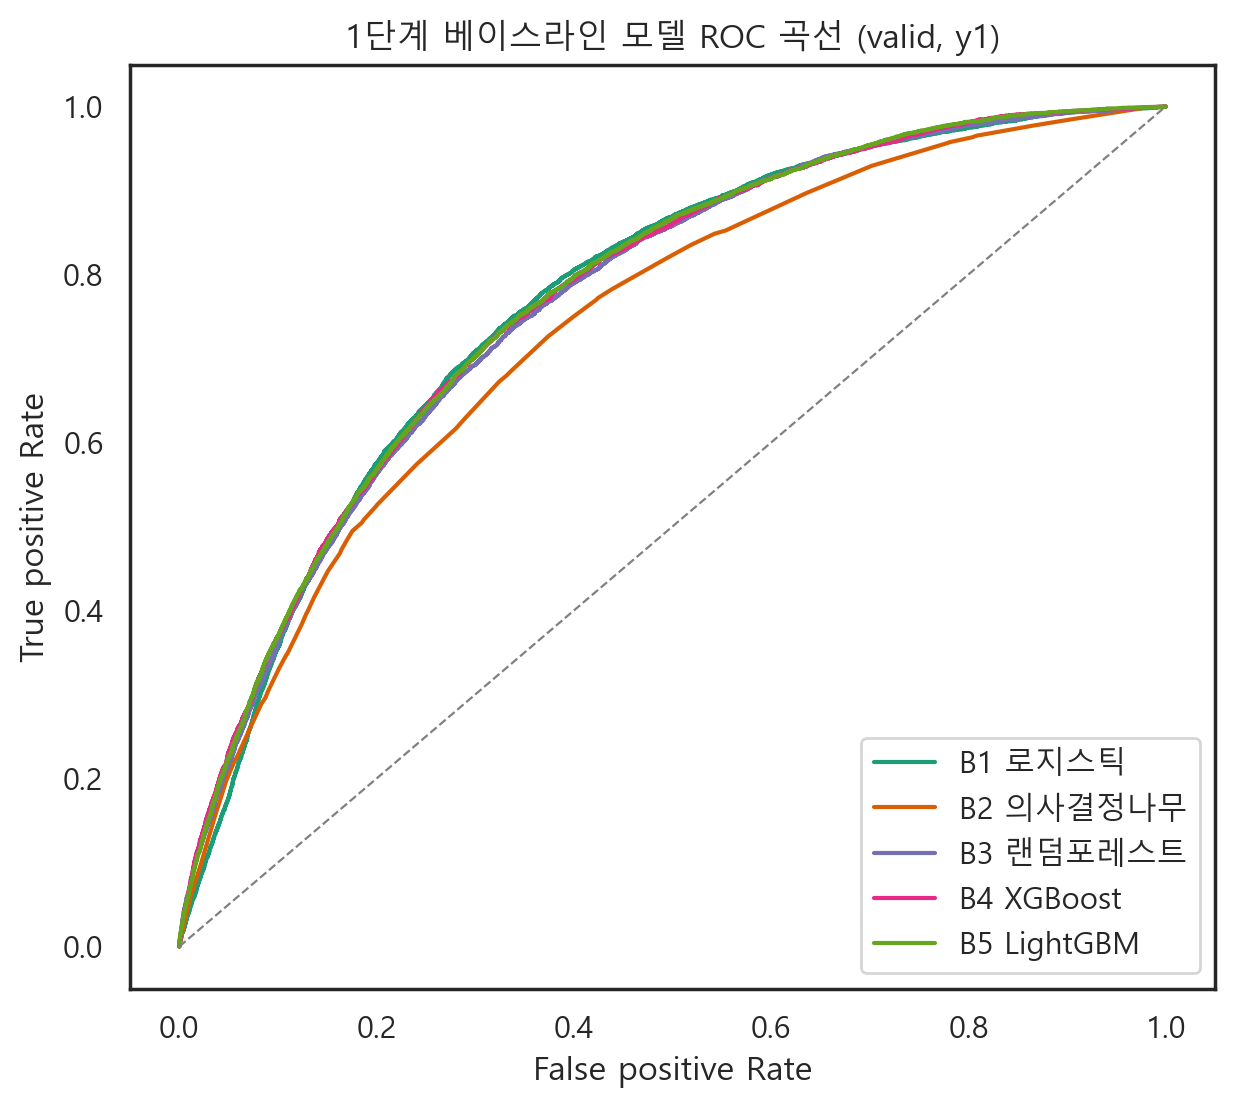

In [131]:
## 5.2 ROC 곡선
fpr1, tpr1, th1 = roc_curve(y_val, 위기확률_lr)
fpr2, tpr2, th2 = roc_curve(y_val, 위기확률_dt)
fpr3, tpr3, th3 = roc_curve(y_val, 위기확률_rf)
fpr4, tpr4, th4 = roc_curve(y_val, 위기확률_xgb)
fpr5, tpr5, th5 = roc_curve(y_val, 위기확률_lgb)

plt.figure(figsize=(7, 6))
plt.plot(fpr1, tpr1, label='B1 로지스틱')
plt.plot(fpr2, tpr2, label='B2 의사결정나무')
plt.plot(fpr3, tpr3, label='B3 랜덤포레스트')
plt.plot(fpr4, tpr4, label='B4 XGBoost')
plt.plot(fpr5, tpr5, label='B5 LightGBM')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=0.8)
plt.xlabel('False positive Rate')
plt.ylabel('True positive Rate')
plt.title('1단계 베이스라인 모델 ROC 곡선 (valid, y1)')
plt.legend(loc='lower right')
plt.savefig('05-1_ROC곡선.png', dpi=150, bbox_inches='tight')
plt.show()

In [132]:
## 5.4 실험기록 저장
result.to_csv('00_data/processed/실험기록.csv', index=False, encoding='utf-8-sig')

In [133]:
# 1절. 패키지로드 & 한글설정 & 경고메세지 ignore
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

%config InlineBackend.figure_format = "retina"
sns.set(style='white', context='notebook', palette='Dark2',
        rc={'figure.figsize': (12,3), 'font.family':'Malgun Gothic', 'axes.unicode_minus':False})

import warnings
warnings.filterwarnings(action='ignore')
pd.set_option('display.max_columns', None)

from sklearn.metrics import accuracy_score, roc_auc_score, recall_score, precision_score, f1_score
from sklearn.base import clone
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [134]:
X_label = pd.read_csv('00_data/processed/feature_cols.csv')['파생변수'].tolist()   # A0 (28개)
y_label = '폐업위기_y1'

In [135]:
## 1.2 데이터 분할 (1단계와 동일)
train_data = df[df['기준_년분기_코드'] <= 20244]
val_data = df[(df['기준_년분기_코드'] >= 20251) & (df['기준_년분기_코드'] <= 20252)]

y_train = train_data[y_label]
y_val = val_data[y_label]
print(train_data.shape, val_data.shape)

(170738, 164) (41759, 164)


In [136]:
## 2.1 A1 : 중요도 상위 (04-1 랜덤포레스트 feature_importances_ 누적 80%, y1 기준 12개)
A1 = ['전체점포수_상대', '개업률_당분기', '업종밀집도', '순증가율', '폐업률_당분기', '유동인구_log',
      '프랜차이즈_비율', '점포당매출_log', '업종', '요일매출_편차', '총매출_log', '영역면적_log']

## 2.2 A2 : 핵심 요인 그룹 (03-3 상관분석 상위 3그룹 : 점포·경쟁 + 매출 + 유동인구 + 업종, 19개)
A2 = ['전체점포수_상대', '폐업률_당분기', '개업률_당분기', '프랜차이즈_비율', '순증가율', '업종밀집도',
      '총매출_log', '점포당매출_log', '건당단가_log', '주말매출_비중', '저녁야간매출_비중',
      '심야매출_비중', '2030매출_비중', '요일매출_편차',
      '유동인구_log', '2030유동_비중', '야간유동_비중', '주말유동_비중',
      '업종']

## 2.3 A3 : 점포 규모 제외 (A0에서 규모 변수 3개 제외, 25개)
A3 = [c for c in X_label if c not in ['전체점포수_상대', '업종밀집도', '점포당매출_log']]

## 2.4 A4 : 선형 모델용 (A0에서 상관 0.7 이상 쌍의 한쪽 제거, 24개)
A4 = [c for c in X_label if c not in ['점포당매출_log', '유동인구_log', '상권구분', '폐업개월_상대']]

In [137]:
# 모델1
lgb_model = LGBMClassifier(n_estimators=300, 
                          learning_rate=0.1, 
                          num_leaves=31,
                          class_weight='balanced', 
                          n_jobs=-1, 
                          verbose=-1)

# 모델2
xgb_model = XGBClassifier(n_estimators=300,              
                          learning_rate=0.1,             
                          max_depth=6,
                          scale_pos_weight=spw,            
                          eval_metric='logloss',
                          n_jobs=-1)

In [138]:
## 4.1 E06 : A1 × 모델①
lgb_model.fit(train_data[A1], y_train)

위기확률 = lgb_model.predict_proba(val_data[A1])[:, 1]
예측값 = (위기확률 >= 0.5).astype(int)

acc = accuracy_score(y_val, 예측값)
auc = roc_auc_score(y_val, 위기확률)
rec = recall_score(y_val, 예측값)
pre = precision_score(y_val, 예측값)
f1  = f1_score(y_val, 예측값)
print(f'정확도 {acc:.4f} | AUC {auc:.4f} | 재현율 {rec:.4f} | 정밀도 {pre:.4f} | F1 {f1:.4f}')

record.append({'실험ID': 'E06', '단계': 2, '변수군': 'A1', '변수수': len(A1),
               '모델': 'B5 LightGBM', 'H': 'H0', 'y': y_label,
               '정확도': round(acc, 4), 'valid_AUC': round(auc, 4), '재현율': round(rec, 4),
               '정밀도': round(pre, 4), 'F1': round(f1, 4)})

정확도 0.6902 | AUC 0.7710 | 재현율 0.7248 | 정밀도 0.3534 | F1 0.4752


In [139]:
## 4.1 E07 : A1 × 모델②
xgb_model.fit(train_data[A1], y_train)

위기확률 = xgb_model.predict_proba(val_data[A1])[:, 1]
예측값 = (위기확률 >= 0.5).astype(int)

acc = accuracy_score(y_val, 예측값)
auc = roc_auc_score(y_val, 위기확률)
rec = recall_score(y_val, 예측값)
pre = precision_score(y_val, 예측값)
f1  = f1_score(y_val, 예측값)
print(f'정확도 {acc:.4f} | AUC {auc:.4f} | 재현율 {rec:.4f} | 정밀도 {pre:.4f} | F1 {f1:.4f}')

record.append({'실험ID': 'E07', '단계': 2, '변수군': 'A1', '변수수': len(A1),
               '모델': 'B4 XGBoost', 'H': 'H0', 'y': y_label,
               '정확도': round(acc, 4), 'valid_AUC': round(auc, 4), '재현율': round(rec, 4),
               '정밀도': round(pre, 4), 'F1': round(f1, 4)})

정확도 0.6944 | AUC 0.7697 | 재현율 0.7168 | 정밀도 0.3561 | F1 0.4758


In [144]:
## 4.1 E08 : A2 × 모델①
lgb_model.fit(train_data[A2], y_train)

위기확률 = lgb_model.predict_proba(val_data[A2])[:, 1]
예측값 = (위기확률 >= 0.5).astype(int)

acc = accuracy_score(y_val, 예측값)
auc = roc_auc_score(y_val, 위기확률)
rec = recall_score(y_val, 예측값)
pre = precision_score(y_val, 예측값)
f1  = f1_score(y_val, 예측값)
print(f'정확도 {acc:.4f} | AUC {auc:.4f} | 재현율 {rec:.4f} | 정밀도 {pre:.4f} | F1 {f1:.4f}')

record.append({'실험ID': 'E08', '단계': 2, '변수군': 'A2', '변수수': len(A2),
               '모델': 'B5 LightGBM', 'H': 'H0', 'y': y_label,
               '정확도': round(acc, 4), 'valid_AUC': round(auc, 4), '재현율': round(rec, 4),
               '정밀도': round(pre, 4), 'F1': round(f1, 4)})

정확도 0.6911 | AUC 0.7691 | 재현율 0.7164 | 정밀도 0.3530 | F1 0.4730


In [140]:
## 4.1 E09 : A2 × 모델②
xgb_model.fit(train_data[A2], y_train)

위기확률 = xgb_model.predict_proba(val_data[A2])[:, 1]
예측값 = (위기확률 >= 0.5).astype(int)

acc = accuracy_score(y_val, 예측값)
auc = roc_auc_score(y_val, 위기확률)
rec = recall_score(y_val, 예측값)
pre = precision_score(y_val, 예측값)
f1  = f1_score(y_val, 예측값)
print(f'정확도 {acc:.4f} | AUC {auc:.4f} | 재현율 {rec:.4f} | 정밀도 {pre:.4f} | F1 {f1:.4f}')

record.append({'실험ID': 'E09', '단계': 2, '변수군': 'A2', '변수수': len(A2),
               '모델': 'B4 XGBoost', 'H': 'H0', 'y': y_label,
               '정확도': round(acc, 4), 'valid_AUC': round(auc, 4), '재현율': round(rec, 4),
               '정밀도': round(pre, 4), 'F1': round(f1, 4)})

정확도 0.6999 | AUC 0.7688 | 재현율 0.7034 | 정밀도 0.3593 | F1 0.4756


In [146]:
## 4.1 E10 : A3 × 모델①
lgb_model.fit(train_data[A3], y_train)

위기확률 = lgb_model.predict_proba(val_data[A3])[:, 1]
예측값 = (위기확률 >= 0.5).astype(int)

acc = accuracy_score(y_val, 예측값)
auc = roc_auc_score(y_val, 위기확률)
rec = recall_score(y_val, 예측값)
pre = precision_score(y_val, 예측값)
f1  = f1_score(y_val, 예측값)
print(f'정확도 {acc:.4f} | AUC {auc:.4f} | 재현율 {rec:.4f} | 정밀도 {pre:.4f} | F1 {f1:.4f}')

record.append({'실험ID': 'E10', '단계': 2, '변수군': 'A3', '변수수': len(A3),
               '모델': 'B5 LightGBM', 'H': 'H0', 'y': y_label,
               '정확도': round(acc, 4), 'valid_AUC': round(auc, 4), '재현율': round(rec, 4),
               '정밀도': round(pre, 4), 'F1': round(f1, 4)})

정확도 0.7046 | AUC 0.7445 | 재현율 0.6521 | 정밀도 0.3561 | F1 0.4607


In [141]:
## 4.1 E11 : A3 × 모델②
xgb_model.fit(train_data[A3], y_train)

위기확률 = xgb_model.predict_proba(val_data[A3])[:, 1]
예측값 = (위기확률 >= 0.5).astype(int)

acc = accuracy_score(y_val, 예측값)
auc = roc_auc_score(y_val, 위기확률)
rec = recall_score(y_val, 예측값)
pre = precision_score(y_val, 예측값)
f1  = f1_score(y_val, 예측값)
print(f'정확도 {acc:.4f} | AUC {auc:.4f} | 재현율 {rec:.4f} | 정밀도 {pre:.4f} | F1 {f1:.4f}')

record.append({'실험ID': 'E11', '단계': 2, '변수군': 'A3', '변수수': len(A3),
               '모델': 'B4 XGBoost', 'H': 'H0', 'y': y_label,
               '정확도': round(acc, 4), 'valid_AUC': round(auc, 4), '재현율': round(rec, 4),
               '정밀도': round(pre, 4), 'F1': round(f1, 4)})

정확도 0.7058 | AUC 0.7443 | 재현율 0.6466 | 정밀도 0.3565 | F1 0.4596


In [147]:
result = pd.DataFrame(record)
result.sort_values('valid_AUC', ascending=False)

,실험ID,단계,변수군,변수수,모델,H,y,정확도,valid_AUC,재현율,정밀도,F1
5,E06,2,A1,12,B5 LightGBM,H0,폐업위기_y1,0.6902,0.7710,0.7248,0.3534,0.4752
4,E05,1,A0,28,B5 LightGBM,H0,폐업위기_y1,0.6919,0.7698,0.7208,0.3543,0.4751
6,E07,2,A1,12,B4 XGBoost,H0,폐업위기_y1,0.6944,0.7697,0.7168,0.3561,0.4758
3,E04,1,A0,28,B4 XGBoost,H0,폐업위기_y1,0.6980,0.7692,0.7068,0.3579,0.4752
9,E08,2,A2,19,B5 LightGBM,H0,폐업위기_y1,0.6911,0.7691,0.7164,0.3530,0.4730
7,E09,2,A2,19,B4 XGBoost,H0,폐업위기_y1,0.6999,0.7688,0.7034,0.3593,0.4756
0,E01,1,A0(원핫),96,B1 로지스틱,H0,폐업위기_y1,0.6903,0.7652,0.7096,0.3513,0.4699
2,E03,1,A0,28,B3 랜덤포레스트,H0,폐업위기_y1,0.7097,0.7651,0.6745,0.3647,0.4734
10,E10,2,A3,25,B5 LightGBM,H0,폐업위기_y1,0.7046,0.7445,0.6521,0.3561,0.4607
8,E11,2,A3,25,B4 XGBoost,H0,폐업위기_y1,0.7058,0.7443,0.6466,0.3565,0.4596


In [ ]:
## 최적 변수군 : A1 선택사유
# 1. AUC value 가장 높음 / 변수 축소 가능

In [148]:
## 2.1 GridSearchCV용 데이터 : 2023Q1 ~ 2025Q2 (train + valid 기간)를 데이터셋에서 바로 추출
data_CV = df[df['기준_년분기_코드'] <= 20252]
X_CV = data_CV[A1]
y_CV = data_CV[y_label]
print(X_CV.shape, y_CV.shape) 

## 3.1 탐색 범위 (B5 LightGBM, 3 × 2 × 2 = 12개 조합)
from sklearn.model_selection import PredefinedSplit, GridSearchCV
fold = np.where(data_CV['기준_년분기_코드'] <= 20244, -1, 0)
ps = PredefinedSplit(fold)
print('학습 행 :', (fold == -1).sum(), '/ 평가 행 :', (fold == 0).sum()) 

param_grid = {'num_leaves': [15, 31, 63],            # 트리 하나의 최대 잎 수 (클수록 복잡)
              'learning_rate': [0.05, 0.1],          # 학습률 (작을수록 천천히, 정교하게)
              'min_child_samples': [20, 50]}         # 잎 하나의 최소 데이터 수 (클수록 과적합 방지)

lgb_model = LGBMClassifier(n_estimators=300,             # 트리 갯수 (H0과 동일하게 고정)
                        class_weight='balanced',
                        n_jobs=-1,
                        verbose=-1)
grid_search = GridSearchCV(lgb_model,
                           param_grid,
                           scoring='roc_auc',      # 평가 기준
                           cv=ps,                  # 시간순 분할 (train → valid)
                           refit=False,            # 최적 조합을 train+valid로 다시 학습하지 않음
                           verbose=1)              # 진행 상황 출력
grid_search.fit(X_CV, y_CV)

(212497, 12) (212497,)
학습 행 : 170738 / 평가 행 : 41759
Fitting 1 folds for each of 12 candidates, totalling 12 fits


GridSearchCV(cv=PredefinedSplit(test_fold=array([-1, -1, ...,  0,  0])),
             estimator=LGBMClassifier(class_weight='balanced', n_estimators=300,
                                      n_jobs=-1, verbose=-1),
             param_grid={'learning_rate': [0.05, 0.1],
                         'min_child_samples': [20, 50],
                         'num_leaves': [15, 31, 63]},
             refit=False, scoring='roc_auc', verbose=1)

In [92]:
## 3.2 탐색 결과 확인
print('최적 파라미터 :', grid_search.best_params_)
print('최고 valid AUC :', round(grid_search.best_score_, 4))

grid_result = pd.DataFrame(grid_search.cv_results_)[['params', 'mean_test_score', 'rank_test_score']]
grid_result.sort_values('rank_test_score')

최적 파라미터 : {'learning_rate': 0.05, 'min_child_samples': 50, 'num_leaves': 63}
최고 valid AUC : 0.7725


,params,mean_test_score,rank_test_score
5,"{'learning_rate': 0.05, 'min_child_samples': 5...",0.772525,1
9,"{'learning_rate': 0.1, 'min_child_samples': 50...",0.772206,2
4,"{'learning_rate': 0.05, 'min_child_samples': 5...",0.772143,3
10,"{'learning_rate': 0.1, 'min_child_samples': 50...",0.771684,4
2,"{'learning_rate': 0.05, 'min_child_samples': 2...",0.771604,5
6,"{'learning_rate': 0.1, 'min_child_samples': 20...",0.771515,6
1,"{'learning_rate': 0.05, 'min_child_samples': 2...",0.771152,7
7,"{'learning_rate': 0.1, 'min_child_samples': 20...",0.771022,8
3,"{'learning_rate': 0.05, 'min_child_samples': 5...",0.770675,9
0,"{'learning_rate': 0.05, 'min_child_samples': 2...",0.770555,10


In [149]:
## 3.3 최적 파라미터로 train만 다시 학습 (A1 변수 12개)
best_model = LGBMClassifier(**grid_search.best_params_,     # 찾은 최적 조합
                            n_estimators=300,
                            class_weight='balanced',
                            n_jobs=-1,
                            verbose=-1)
best_model.fit(train_data[A1], y_train)

LGBMClassifier(class_weight='balanced', learning_rate=0.05,
               min_child_samples=50, n_estimators=300, n_jobs=-1, num_leaves=63,
               verbose=-1)

In [150]:
## 3.4 E12 검증
위기확률_best = best_model.predict_proba(valid_data[A1])[:, 1]
예측값_best = (위기확률_best >= 0.5).astype(int)

acc = accuracy_score(y_val, 예측값_best)
auc = roc_auc_score(y_val, 위기확률_best)
rec = recall_score(y_val, 예측값_best)
pre = precision_score(y_val, 예측값_best)
f1  = f1_score(y_val, 예측값_best)
print(f'정확도 {acc:.4f} | AUC {auc:.4f} | 재현율 {rec:.4f} | 정밀도 {pre:.4f} | F1 {f1:.4f}')

record.append({'실험ID': 'E12', '단계': 3, '변수군': 'A1', '변수수': len(A1),
               '모델': 'B5 LightGBM', 'H': 'H1', 'y': y_label,
               '정확도': round(acc, 4), 'valid_AUC': round(auc, 4), '재현율': round(rec, 4),
               '정밀도': round(pre, 4), 'F1': round(f1, 4),
               '파라미터': str(grid_search.best_params_)})

정확도 0.6902 | AUC 0.7725 | 재현율 0.7241 | 정밀도 0.3533 | F1 0.4749


In [151]:
## 4.1 튜닝 효과 : 같은 A1 × LightGBM의 H0(E06)과 비교
result = pd.DataFrame(record)
result[result['모델'] == 'B5 LightGBM'][['실험ID', '변수군', 'H', 'valid_AUC', '재현율', 'F1']]

,실험ID,변수군,H,valid_AUC,재현율,F1
4,E05,A0,H0,0.7698,0.7208,0.4751
5,E06,A1,H0,0.7710,0.7248,0.4752
9,E08,A2,H0,0.7691,0.7164,0.4730
10,E10,A3,H0,0.7445,0.6521,0.4607
11,E12,A1,H1,0.7725,0.7241,0.4749


In [152]:
## 3.5 E13 탐색 범위 (B4 XGBoost, 2 × 3 × 2 = 12개 조합)
spw = (y_train == 0).sum() / (y_train == 1).sum()       # 정상 수 ÷ 위기 수 (불균형 보정)
print('scale_pos_weight :', round(spw, 2))

param_grid = {'learning_rate': [0.05, 0.1],             # 학습률 (작을수록 천천히, 정교하게)
              'max_depth': [4, 6, 8],                   # 트리 최대 깊이
              'n_estimators': [300, 600]}               # 트리 갯수

xgb_model = XGBClassifier(scale_pos_weight=spw,           # 탐색하지 않는 설정만 넣음
                         eval_metric='logloss',
                         n_jobs=-1)

scale_pos_weight : 3.92


In [153]:
## 3.6 GridSearchCV 실행 (12개 조합)
grid_search_xgb = GridSearchCV(xgb_model,
                               param_grid,
                               scoring='roc_auc',      # 평가 기준
                               cv=ps,                  # 시간순 분할 (train → valid)
                               refit=False,            # 최적 조합을 다시 학습하지 않음 (아래에서 직접)
                               verbose=1)
grid_search_xgb.fit(X_CV, y_CV)

Fitting 1 folds for each of 12 candidates, totalling 12 fits


GridSearchCV(cv=PredefinedSplit(test_fold=array([-1, -1, ...,  0,  0])),
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=...
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=-1, num_parallel_tree=None, ...),
             param_grid={'learning_rate': [0.05, 0.1], 'max_depth': [4, 6, 8],
                         'n_estimators': [300, 600]},
             refit=False, scoring='roc_auc', verbose=1)

In [154]:
## 3.7 탐색 결과 확인
print('최적 파라미터 :', grid_search_xgb.best_params_)
print('최고 valid AUC :', round(grid_search_xgb.best_score_, 4))

grid_result_xgb = pd.DataFrame(grid_search_xgb.cv_results_)[['params', 'mean_test_score', 'rank_test_score']]
grid_result_xgb.sort_values('rank_test_score')

최적 파라미터 : {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 600}
최고 valid AUC : 0.7725


,params,mean_test_score,rank_test_score
7,"{'learning_rate': 0.1, 'max_depth': 4, 'n_esti...",0.772483,1
1,"{'learning_rate': 0.05, 'max_depth': 4, 'n_est...",0.772107,2
6,"{'learning_rate': 0.1, 'max_depth': 4, 'n_esti...",0.771984,3
2,"{'learning_rate': 0.05, 'max_depth': 6, 'n_est...",0.771426,4
4,"{'learning_rate': 0.05, 'max_depth': 8, 'n_est...",0.769853,5
3,"{'learning_rate': 0.05, 'max_depth': 6, 'n_est...",0.769815,6
8,"{'learning_rate': 0.1, 'max_depth': 6, 'n_esti...",0.769675,7
0,"{'learning_rate': 0.05, 'max_depth': 4, 'n_est...",0.769407,8
9,"{'learning_rate': 0.1, 'max_depth': 6, 'n_esti...",0.764383,9
5,"{'learning_rate': 0.05, 'max_depth': 8, 'n_est...",0.763610,10


In [155]:
## 3.8 최적 파라미터로 train만 다시 학습 (A1 변수 12개)
best_xgb = XGBClassifier(**grid_search_xgb.best_params_,    # 찾은 최적 조합
                         scale_pos_weight=spw,
                         eval_metric='logloss',
                         n_jobs=-1)
best_xgb.fit(train_data[A1], y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=600, n_jobs=-1,
              num_parallel_tree=None, ...)

In [156]:
## 3.9 E13 검증
위기확률_best_xgb = best_xgb.predict_proba(valid_data[A1])[:, 1]
예측값_best_xgb = (위기확률_best_xgb >= 0.5).astype(int)

acc = accuracy_score(y_val, 예측값_best_xgb)
auc = roc_auc_score(y_val, 위기확률_best_xgb)
rec = recall_score(y_val, 예측값_best_xgb)
pre = precision_score(y_val, 예측값_best_xgb)
f1  = f1_score(y_val, 예측값_best_xgb)
print(f'정확도 {acc:.4f} | AUC {auc:.4f} | 재현율 {rec:.4f} | 정밀도 {pre:.4f} | F1 {f1:.4f}')

record.append({'실험ID': 'E13', '단계': 3, '변수군': 'A1', '변수수': len(A1),
               '모델': 'B4 XGBoost', 'H': 'H1', 'y': y_label,
               '정확도': round(acc, 4), 'valid_AUC': round(auc, 4), '재현율': round(rec, 4),
               '정밀도': round(pre, 4), 'F1': round(f1, 4),
               '파라미터': str(grid_search_xgb.best_params_)})

정확도 0.6879 | AUC 0.7725 | 재현율 0.7364 | 정밀도 0.3530 | F1 0.4772


In [157]:
## 4.1 E12와 E13 비교 (+ 각 모델의 H0 결과)
result = pd.DataFrame(record)
result[result['실험ID'].isin(['E04', 'E05', 'E06', 'E07', 'E12', 'E13'])][['실험ID', '변수군', '모델', 'H', 'valid_AUC', '재현율', 'F1']]

,실험ID,변수군,모델,H,valid_AUC,재현율,F1
3,E04,A0,B4 XGBoost,H0,0.7692,0.7068,0.4752
4,E05,A0,B5 LightGBM,H0,0.7698,0.7208,0.4751
5,E06,A1,B5 LightGBM,H0,0.7710,0.7248,0.4752
6,E07,A1,B4 XGBoost,H0,0.7697,0.7168,0.4758
11,E12,A1,B5 LightGBM,H1,0.7725,0.7241,0.4749
12,E13,A1,B4 XGBoost,H1,0.7725,0.7364,0.4772


In [ ]:
##"튜닝 후 LightGBM(E12)과 XGBoost(E13)의 검증 AUC가 0.7725로 동일하여, 
##위기 상권 탐지가 중요한 서비스 목적에 따라 재현율이 더 높은 XGBoost(재현율 0.736)를 최종후보로 선정

In [158]:
## 4.0 엄격 기준 종속변수 (y2)
y2_label = '폐업위기_엄격_y2'

y2_train = train_data[y2_label]
y2_val = valid_data[y2_label]

print('train 위기 비율 :', round(y2_train.mean() * 100, 1), '%')     # 약 14.8%
print('valid 위기 비율 :', round(y2_val.mean() * 100, 1), '%')

train 위기 비율 : 14.8 %
valid 위기 비율 : 14.2 %


In [159]:
## 4.0.1 y2용 변수군 A1_y2 (04-1 변수중요도를 y2로 계산한 누적 80%, 15개)
A1_y2 = ['전체점포수_상대', '업종밀집도', '개업률_당분기', '순증가율', '유동인구_log', '점포당매출_log',
         '총매출_log', '업종', '프랜차이즈_비율', '요일매출_편차', '저녁야간매출_비중', '폐업률_당분기',
         '영역면적_log', '건당단가_log', '2030매출_비중']
print(len(A1_y2), '개')

15 개


In [161]:
## 4.1 E14 모델 정의 (1단계 E03과 같은 H0 설정)
rf_y2 = RandomForestClassifier(n_estimators=200,
                               max_depth=12,
                               min_samples_leaf=50,
                               class_weight='balanced',
                               n_jobs=-1)
## 4.1.1 E14 학습 (A0 28개)
rf_y2.fit(train_data[X_label], y2_train)

RandomForestClassifier(class_weight='balanced', max_depth=12,
                       min_samples_leaf=50, n_estimators=200, n_jobs=-1)

In [162]:
## 4.1.2 E14 검증
위기확률_rf_y2 = rf_y2.predict_proba(valid_data[X_label])[:, 1]
예측값_rf_y2 = (위기확률_rf_y2 >= 0.5).astype(int)

acc = accuracy_score(y2_val, 예측값_rf_y2)
auc = roc_auc_score(y2_val, 위기확률_rf_y2)
rec = recall_score(y2_val, 예측값_rf_y2)
pre = precision_score(y2_val, 예측값_rf_y2)
f1  = f1_score(y2_val, 예측값_rf_y2)
print(f'정확도 {acc:.4f} | AUC {auc:.4f} | 재현율 {rec:.4f} | 정밀도 {pre:.4f} | F1 {f1:.4f}')

record.append({'실험ID': 'E14', '단계': 4, '변수군': 'A0', '변수수': len(X_label),
               '모델': 'B3 랜덤포레스트', 'H': 'H0', 'y': y2_label,
               '정확도': round(acc, 4), 'valid_AUC': round(auc, 4), '재현율': round(rec, 4),
               '정밀도': round(pre, 4), 'F1': round(f1, 4)})

정확도 0.6433 | AUC 0.6996 | 재현율 0.6413 | 정밀도 0.2297 | F1 0.3382


In [163]:
## 4.2 E15 모델 정의 : E13 최적 파라미터 + y2용 불균형 보정값
spw_y2 = (y2_train == 0).sum() / (y2_train == 1).sum()     # y2는 위기 비율이 낮아 약 5.7
print('scale_pos_weight (y2) :', round(spw_y2, 2))
print('E13 최적 파라미터 :', grid_search_xgb.best_params_)

xgb_y2 = XGBClassifier(**grid_search_xgb.best_params_,
                       scale_pos_weight=spw_y2,
                       eval_metric='logloss',
                       n_jobs=-1)
## 4.2.1 E15 학습 (A1_y2 15개)
xgb_y2.fit(train_data[A1_y2], y2_train)

scale_pos_weight (y2) : 5.73
E13 최적 파라미터 : {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 600}


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=600, n_jobs=-1,
              num_parallel_tree=None, ...)

In [164]:
## 4.2.2 E15 검증
위기확률_xgb_y2 = xgb_y2.predict_proba(valid_data[A1_y2])[:, 1]
예측값_xgb_y2 = (위기확률_xgb_y2 >= 0.5).astype(int)

acc = accuracy_score(y2_val, 예측값_xgb_y2)
auc = roc_auc_score(y2_val, 위기확률_xgb_y2)
rec = recall_score(y2_val, 예측값_xgb_y2)
pre = precision_score(y2_val, 예측값_xgb_y2)
f1  = f1_score(y2_val, 예측값_xgb_y2)
print(f'정확도 {acc:.4f} | AUC {auc:.4f} | 재현율 {rec:.4f} | 정밀도 {pre:.4f} | F1 {f1:.4f}')

record.append({'실험ID': 'E15', '단계': 4, '변수군': 'A1_y2', '변수수': len(A1_y2),
               '모델': 'B4 XGBoost', 'H': 'H1(E13)', 'y': y2_label,
               '정확도': round(acc, 4), 'valid_AUC': round(auc, 4), '재현율': round(rec, 4),
               '정밀도': round(pre, 4), 'F1': round(f1, 4),
               '파라미터': str(grid_search_xgb.best_params_)})

정확도 0.6124 | AUC 0.7068 | 재현율 0.7061 | 정밀도 0.2249 | F1 0.3412


In [165]:
## 4.3 y1 vs y2 비교
result = pd.DataFrame(record).sort_values('실험ID').reset_index(drop=True)
result[result['실험ID'].isin(['E03', 'E13', 'E14', 'E15'])][['실험ID', '변수군', '모델', 'H', 'y', 'valid_AUC', '재현율', '정밀도', 'F1']]

,실험ID,변수군,모델,H,y,valid_AUC,재현율,정밀도,F1
2,E03,A0,B3 랜덤포레스트,H0,폐업위기_y1,0.7651,0.6745,0.3647,0.4734
12,E13,A1,B4 XGBoost,H1,폐업위기_y1,0.7725,0.7364,0.3530,0.4772
13,E14,A0,B3 랜덤포레스트,H0,폐업위기_엄격_y2,0.6996,0.6413,0.2297,0.3382
14,E15,A1_y2,B4 XGBoost,H1(E13),폐업위기_엄격_y2,0.7068,0.7061,0.2249,0.3412


In [166]:
## 4.4 실험기록 저장
result.to_csv('00_data/processed/실험기록.csv', index=False, encoding='utf-8-sig')

In [ ]:
##"5개 모델과 3개 변수군, 하이퍼파라미터 튜닝을 단계적으로 비교한 결과, 
## 중요도 상위 12개 변수와 튜닝된 XGBoost 조합이 가장 우수하였다(검증 AUC 0.773, 재현율 0.736). 
## 이 조합은 엄격 기준(y2)에서도 베이스라인보다 개선되어 일반성을 보였으며, 두 기준 중 변별력이 높은 기본 
##  기준(y1)을 서비스 예측 기준으로 채택하였다."

In [167]:
## 5.1 기준값별 재현율·정밀도·F1 비교 (E13 모델, valid)
기준표 = []
for 기준 in [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7]:
    예측값 = (위기확률_best_xgb >= 기준).astype(int)
    기준표.append({'기준값': 기준,
                  '위기판정_비율': round(예측값.mean(), 4),
                  '재현율': round(recall_score(y_val, 예측값), 4),
                  '정밀도': round(precision_score(y_val, 예측값), 4),
                  'F1': round(f1_score(y_val, 예측값), 4),
                  '정확도': round(accuracy_score(y_val, 예측값), 4)})

기준표 = pd.DataFrame(기준표)
기준표

,기준값,위기판정_비율,재현율,정밀도,F1,정확도
0,0.30,0.6611,0.9194,0.2691,0.4163,0.5012
1,0.35,0.5963,0.8830,0.2865,0.4326,0.5519
2,0.40,0.5289,0.8403,0.3074,0.4501,0.6027
3,0.45,0.4651,0.7909,0.3290,0.4647,0.6474
4,0.50,0.4036,0.7364,0.3530,0.4772,0.6879
5,0.55,0.3413,0.6633,0.3760,0.4800,0.7219
6,0.60,0.2837,0.5853,0.3992,0.4747,0.7493
7,0.65,0.2292,0.5063,0.4272,0.4634,0.7732
8,0.70,0.1695,0.4052,0.4626,0.4320,0.7938


In [168]:
## 5.1.1 F1이 가장 높은 기준값 선택
최종기준 = 기준표.sort_values('F1', ascending=False).iloc[0]['기준값']
print('최종 기준값 :', 최종기준)

최종 기준값 : 0.55


In [170]:
## 5.2 위기확률 10분위별 실제 위기 비율 (valid)
분위표 = pd.DataFrame({'위기확률': 위기확률_best_xgb, '실제위기': y_val.values})
분위표['구간'] = pd.qcut(분위표['위기확률'], q=10, labels=['하위10%', '10~20%', '20~30%', '30~40%', '40~50%',
                                                       '50~60%', '60~70%', '70~80%', '80~90%', '상위10%'])

분위결과 = 분위표.groupby('구간').agg(최소확률=('위기확률', 'min'),
                                 실제위기_비율=('실제위기', 'mean'),
                                 상권수=('실제위기', 'size')).round(3)
분위결과['평균대비_배수'] = (분위결과['실제위기_비율'] / y_val.mean()).round(2)
분위결과

,최소확률,실제위기_비율,상권수,평균대비_배수
구간,,,,
하위10%,0.002,0.013,4176,0.07
10~20%,0.081,0.036,4176,0.19
20~30%,0.174,0.075,4176,0.39
30~40%,0.270,0.099,4176,0.51
40~50%,0.347,0.125,4176,0.65
50~60%,0.424,0.167,4175,0.86
60~70%,0.503,0.239,4176,1.24
70~80%,0.586,0.289,4176,1.49
80~90%,0.675,0.381,4176,1.97


In [ ]:
##검증 데이터의 위기확률 10분위 분석에서 실제 위기 비율이 평균의 0.5배 미만인 하위 30%를 '양호', 평균의 약 2배 이상인 상위 20%를 '위험'으로 구분하였다.

In [181]:
## 5.2.1 등급 경계 : 하위 30% 양호, 상위 20% 위험
경계_중간 = np.quantile(위기확률_best_xgb, 0.3)
경계_위험 = np.quantile(위기확률_best_xgb, 0.8)
print('양호 / 중간 경계 :', round(경계_중간, 4))     # 약 0.174
print('중간 / 위험 경계 :', round(경계_위험, 4))     # 약 0.675

양호 / 중간 경계 : 0.2701
중간 / 위험 경계 : 0.675


In [174]:
## 5.3 test 데이터 (2025년 3분기)
test_data = df[df['기준_년분기_코드'] == 20253]
y_test = test_data[y_label]
print(test_data.shape, '위기 비율', round(y_test.mean() * 100, 1), '%')

(20920, 164) 위기 비율 18.4 %


In [175]:
## 5.3.1 E16 : E13 모델(best_xgb)로 test 평가 — 이 셀은 한 번만 실행
위기확률_test = best_xgb.predict_proba(test_data[A1])[:, 1]
예측값_test = (위기확률_test >= 최종기준).astype(int)

acc = accuracy_score(y_test, 예측값_test)
auc = roc_auc_score(y_test, 위기확률_test)
rec = recall_score(y_test, 예측값_test)
pre = precision_score(y_test, 예측값_test)
f1  = f1_score(y_test, 예측값_test)
print(f'[test] 정확도 {acc:.4f} | AUC {auc:.4f} | 재현율 {rec:.4f} | 정밀도 {pre:.4f} | F1 {f1:.4f}')

record.append({'실험ID': 'E16', '단계': 5, '변수군': 'A1', '변수수': len(A1),
               '모델': 'B4 XGBoost', 'H': 'H1', 'y': y_label,
               '정확도': round(acc, 4), 'valid_AUC': round(auc, 4), '재현율': round(rec, 4),
               '정밀도': round(pre, 4), 'F1': round(f1, 4),
               '파라미터': str(grid_search_xgb.best_params_) + f' / 기준값 {최종기준}'})

[test] 정확도 0.7170 | AUC 0.7678 | 재현율 0.6616 | 정밀도 0.3549 | F1 0.4620


In [184]:
## 5.3.2 test 상권에 두 가지 결과 붙이기
test_결과 = pd.DataFrame({'위기확률': 위기확률_test, '실제위기': y_test.values})

# 방법 ① : 기준값 이상이면 위기, 미만이면 양호
test_결과['위기판정'] = np.where(test_결과['위기확률'] >= 최종기준, '위기', '양호')

# 방법 ② : valid에서 정한 경계로 양호(하위 30%) / 중간(30~80%) / 위험(상위 20%)
test_결과['위험등급'] = pd.cut(test_결과['위기확률'],
                            bins=[0, 경계_중간, 경계_위험, 1],
                            labels=['양호', '중간', '위험'],
                            include_lowest=True)
test_결과.head()

,위기확률,실제위기,위기판정,위험등급
0,0.728569,0.0,위기,위험
1,0.653401,1.0,위기,중간
2,0.707608,0.0,위기,위험
3,0.757974,0.0,위기,위험
4,0.755508,0.0,위기,위험


In [185]:
## 5.3.3 방법 ① : 위기 / 양호 판정별 실제 위기 비율 (test)
판정결과 = test_결과.groupby('위기판정').agg(상권수=('실제위기', 'size'),
                                     실제위기_비율=('실제위기', 'mean')).round(3)
판정결과

,상권수,실제위기_비율
위기판정,,
양호,13758,0.094
위기,7162,0.355


In [186]:
## 5.3.3 방법 ① : 위기판정 × 실제위기 교차표 (test)
pd.crosstab(test_결과['실제위기'], test_결과['위기판정'],
            rownames=['실제위기'], colnames=['위기판정'],
            margins=True)

위기판정,양호,위기,All
실제위기,,,
0.0,12458,4620,17078
1.0,1300,2542,3842
All,13758,7162,20920


In [187]:
## 5.3.4 방법 ② : 등급별 실제 위기 비율 (test)
등급결과 = test_결과.groupby('위험등급').agg(상권수=('실제위기', 'size'),
                                     실제위기_비율=('실제위기', 'mean')).round(3)
등급결과['상권_비중'] = (등급결과['상권수'] / 등급결과['상권수'].sum()).round(3)
등급결과['평균대비_배수'] = (등급결과['실제위기_비율'] / y_test.mean()).round(2)
등급결과

,상권수,실제위기_비율,상권_비중,평균대비_배수
위험등급,,,,
양호,6227,0.039,0.298,0.21
중간,10378,0.172,0.496,0.94
위험,4315,0.420,0.206,2.29


"검증 데이터로 정한 위험 등급 경계를 테스트 데이터(2025년 3분기)에 적용한 결과, 등급별 상권 비중(29.8% / 49.6% / 20.6%)과 실제 위기 비율(양호 3.9%, 중간 17.2%, 위험 42.0%)이 검증 결과와 거의 같게 유지되었다. 위험 등급의 실제 위기 비율은 평균의 2.29배, 양호 등급의 약 10.8배로, 처음 보는 분기에서도 등급이 위기 가능성을 안정적으로 구분하였다."

In [188]:
## 5.4 최종 모델 : y가 있는 전체 기간(2023Q1 ~ 2025Q3)으로 다시 학습
final_data = df[df['기준_년분기_코드'] <= 20253]
y_final = final_data[y_label]

spw_final = (y_final == 0).sum() / (y_final == 1).sum()       # 정상 수 ÷ 위기 수
final_model = XGBClassifier(**grid_search_xgb.best_params_,   # E13 최적 파라미터
                            scale_pos_weight=spw_final,
                            eval_metric='logloss',
                            n_jobs=-1)
final_model.fit(final_data[A1], y_final)
print('최종 학습 행 수 :', len(final_data))

최종 학습 행 수 : 233417


In [189]:
## 5.4.1 2025년 4분기 예측 : 위기확률 + 방법 ①(위기/양호) + 방법 ②(양호/중간/위험)
pred_data = df[df['기준_년분기_코드'] == 20254].copy()
pred_data['위기확률'] = final_model.predict_proba(pred_data[A1])[:, 1]

# 방법 ① : 기준값 이상이면 위기
pred_data['위기판정'] = np.where(pred_data['위기확률'] >= 최종기준, '위기', '양호')

# 방법 ② : 하위 30% 양호, 30~80% 중간, 상위 20% 위험
경계1 = np.quantile(pred_data['위기확률'], 0.3)
경계2 = np.quantile(pred_data['위기확률'], 0.8)
pred_data['위험등급'] = pd.cut(pred_data['위기확률'], bins=[0, 경계1, 경계2, 1],
                           labels=['양호', '중간', '위험'], include_lowest=True)

print('예측 상권 수 :', len(pred_data))
print(pred_data['위기판정'].value_counts())
print(pred_data['위험등급'].value_counts())

예측 상권 수 : 21333
양호    14306
위기     7027
Name: 위기판정, dtype: int64
중간    10666
양호     6400
위험     4267
Name: 위험등급, dtype: int64


In [190]:
## 5.4.2 두 방법 비교 : 같은 상권이 각각 어떻게 분류됐는지
pd.crosstab(pred_data['위험등급'], pred_data['위기판정'],
            rownames=['위험등급'], colnames=['위기판정'], margins=True)

위기판정,양호,위기,All
위험등급,,,
양호,6400,0,6400
중간,7906,2760,10666
위험,0,4267,4267
All,14306,7027,21333


In [191]:
## 5.4.3 위기확률이 높은 상권 상위 10곳
pred_data[['상권_코드_명', '서비스_업종_코드_명', '위기확률', '위기판정', '위험등급']].sort_values('위기확률', ascending=False).head(10)

,상권_코드_명,서비스_업종_코드_명,위기확률,위기판정,위험등급
210764,문정역,한식음식점,0.928242,위기,위험
202415,선릉역,부동산중개업,0.918547,위기,위험
45709,도봉산입구,노래방,0.913895,위기,위험
51978,상계역,노래방,0.913667,위기,위험
172653,구로디지털단지,한식음식점,0.911786,위기,위험
26665,메가박스 상봉,노래방,0.911091,위기,위험
68145,홍대땡땡거리,전자상거래업,0.910959,위기,위험
163557,홍대입구역(홍대),호프-간이주점,0.909753,위기,위험
153426,미아사거리,일반의류,0.908959,위기,위험
169049,발산역(마곡),호프-간이주점,0.907801,위기,위험


In [192]:
## 5.4.4 최종 모델 변수 중요도
중요도 = pd.DataFrame({'변수': A1, '중요도': final_model.feature_importances_}).sort_values('중요도', ascending=False)
중요도

,변수,중요도
1,개업률_당분기,0.318832
0,전체점포수_상대,0.187615
2,업종밀집도,0.092227
5,유동인구_log,0.089812
8,업종,0.060081
6,프랜차이즈_비율,0.050889
3,순증가율,0.041752
7,점포당매출_log,0.041620
4,폐업률_당분기,0.034627
9,요일매출_편차,0.033530


In [193]:
## 5.5 저장 : 모델, 예측 결과, 변수 중요도, 실험기록
import os, joblib
os.makedirs('05_model', exist_ok=True)

joblib.dump(final_model, '05_model/M1_y1_XGBoost.joblib')

pred_data[['기준_년분기_코드', '상권_코드', '상권_코드_명', '서비스_업종_코드', '서비스_업종_코드_명',
           '위기확률', '위기판정', '위험등급']].to_csv('00_data/processed/예측_2025Q4.csv',
                                                index=False, encoding='utf-8-sig')

중요도.to_csv('00_data/processed/최종모델_변수중요도.csv', index=False, encoding='utf-8-sig')

result = pd.DataFrame(record).sort_values('실험ID').reset_index(drop=True)
result.to_csv('00_data/processed/실험기록.csv', index=False, encoding='utf-8-sig')
print('저장 완료')

저장 완료


In [ ]:
####################################### 예시 테스트

In [194]:
## 6.1 입력값 (★ 여기만 바꿔서 테스트)
입력_주소 = '서울 관악구 신림로 330'
입력_업종 = '분식전문점'

## 업종 이름이 예측 데이터에 있는지 확인 (드롭다운 목록 역할)
업종목록 = sorted(pred_data['서비스_업종_코드_명'].unique())
print('선택 가능한 업종 수 :', len(업종목록))
print('입력 업종 확인 :', 입력_업종 in 업종목록)

선택 가능한 업종 수 : 62
입력 업종 확인 : True


In [195]:
## 6.2 주소를 위도·경도로 변환 (카카오 로컬 API, .env에 저장한 REST API 키 사용)
import requests
from dotenv import load_dotenv
load_dotenv()

kakao_key = os.getenv('KAKAO_REST_KEY')       
url = 'https://dapi.kakao.com/v2/local/search/address.json'
r = requests.get(url, headers={'Authorization': f'KakaoAK {kakao_key}'}, params={'query': 입력_주소})

주소결과 = r.json()['documents']
입력_위도 = float(주소결과[0]['y'])
입력_경도 = float(주소결과[0]['x'])
print('좌표 :', 입력_위도, 입력_경도)

좌표 : 37.4838513393186 126.930234545397


In [196]:
## 6.3 입력 좌표와 가장 가까운 상권 (haversine 거리, 단위 m)
상권좌표 = pred_data[['상권_코드', '상권_코드_명', '위도', '경도']].drop_duplicates('상권_코드').copy()

위도1, 경도1 = np.radians(입력_위도), np.radians(입력_경도)
위도2, 경도2 = np.radians(상권좌표['위도']), np.radians(상권좌표['경도'])
a = np.sin((위도2 - 위도1) / 2) ** 2 + np.cos(위도1) * np.cos(위도2) * np.sin((경도2 - 경도1) / 2) ** 2
상권좌표['거리_m'] = 6371000 * 2 * np.arcsin(np.sqrt(a))          # 지구 반지름 6,371km

상권좌표.sort_values('거리_m').head(5)

,상권_코드,상권_코드_명,위도,경도,거리_m
181952,3120157,신림역(신림),37.484724,126.930238,97.062383
248732,3130285,서원동상점가,37.482930,126.928668,172.033614
106654,3110880,신림역 1번,37.483969,126.933461,284.989378
248554,3130283,신원시장,37.482659,126.927029,312.391898
248708,3130284,관악종합시장(신원시장),37.481578,126.928047,317.993278


In [197]:
## 6.4 가까운 상권 순서대로, 입력 업종의 예측 결과가 있는 첫 상권 찾기
가까운순 = 상권좌표.sort_values('거리_m')

for 상권코드, 거리 in zip(가까운순['상권_코드'], 가까운순['거리_m']):
    결과 = pred_data[(pred_data['상권_코드'] == 상권코드) & (pred_data['서비스_업종_코드_명'] == 입력_업종)]
    if len(결과) > 0:
        결과 = 결과.iloc[0]
        break

print('가장 가까운 상권 :', 가까운순.iloc[0]['상권_코드_명'], f"({가까운순.iloc[0]['거리_m']:.0f}m)")
print('예측에 사용한 상권 :', 결과['상권_코드_명'], f'({거리:.0f}m)')

가장 가까운 상권 : 신림역(신림) (97m)
예측에 사용한 상권 : 신림역(신림) (97m)


In [198]:
## 6.5 결과 화면 (웹페이지에 보여 줄 내용)
등급설명 = {'양호': '약 3.9% (서울 평균의 0.2배)',
           '중간': '약 17.2% (서울 평균 수준)',
           '위험': '약 42.0% (서울 평균의 2.3배)'}

같은업종 = pred_data[pred_data['서비스_업종_코드_명'] == 입력_업종]
순위 = (같은업종['위기확률'] > 결과['위기확률']).mean() * 100            # 위기확률이 나보다 높은 비율

업종평균 = df[(df['기준_년분기_코드'] == 20254) & (df['서비스_업종_코드_명'] == 입력_업종)][A1].mean()
상권값 = df[(df['기준_년분기_코드'] == 20254) & (df['상권_코드'] == 결과['상권_코드'])
           & (df['서비스_업종_코드_명'] == 입력_업종)][A1].iloc[0]

print('=' * 50)
print(f"📍 상권 : {결과['상권_코드_명']} (입력 주소에서 {거리:.0f}m)")
print(f'🏷 업종 : {입력_업종}')
print('📅 예측 시점 : 2026년 1분기 (2025년 4분기 데이터 기준)')
print('-' * 50)
print(f"■ 폐업위기 등급 : {결과['위험등급']}")
print(f"   - 이 등급의 실제 위기 비율 : {등급설명[결과['위험등급']]}")
print(f'   - 같은 업종 서울 전체 상권 중 위험도 상위 {순위:.0f}%')
print(f"■ 위기 판정 : {결과['위기판정']}")
print('-' * 50)
print('■ 주요 특징 (이 상권 / 같은 업종 평균)')
print(f"   - 같은 업종 점포 규모 : 업종 평균의 {상권값['전체점포수_상대']:.1f}배")
print(f"   - 이번 분기 개업률 : {상권값['개업률_당분기']:.1f}% / {업종평균['개업률_당분기']:.1f}%")
print(f"   - 이번 분기 폐업률 : {상권값['폐업률_당분기']:.1f}% / {업종평균['폐업률_당분기']:.1f}%")
print(f"   - 유동인구 1만 명당 점포 수 : {상권값['업종밀집도']:.2f} / {업종평균['업종밀집도']:.2f}")
print('=' * 50)

📍 상권 : 신림역(신림) (입력 주소에서 97m)
🏷 업종 : 분식전문점
📅 예측 시점 : 2026년 1분기 (2025년 4분기 데이터 기준)
--------------------------------------------------
■ 폐업위기 등급 : 위험
   - 이 등급의 실제 위기 비율 : 약 42.0% (서울 평균의 2.3배)
   - 같은 업종 서울 전체 상권 중 위험도 상위 15%
■ 위기 판정 : 위기
--------------------------------------------------
■ 주요 특징 (이 상권 / 같은 업종 평균)
   - 같은 업종 점포 규모 : 업종 평균의 2.1배
   - 이번 분기 개업률 : 0.0% / 3.0%
   - 이번 분기 폐업률 : 9.0% / 3.9%
   - 유동인구 1만 명당 점포 수 : 0.05 / 0.20
